<a href="https://colab.research.google.com/github/AchshaBabu-21/ERBB1/blob/main/EGFR_ErbB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

target = new_client.target
target_query = target.search('Epidermal growth factor receptor erbB1')
targets = pd.DataFrame.from_dict(target_query)
targets

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Homo sapiens,Epidermal growth factor receptor,38.0,False,CHEMBL203,"[{'accession': 'P00533', 'component_descriptio...",SINGLE PROTEIN,9606.0
1,[],Homo sapiens,Protein cereblon/Epidermal growth factor receptor,36.0,False,CHEMBL4523680,"[{'accession': 'P00533', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606.0
2,[],Mus musculus,Protein cereblon/Epidermal growth factor receptor,35.0,False,CHEMBL6193841,"[{'accession': 'P00533', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,10090.0
3,[],Mus musculus,Epidermal growth factor receptor,33.0,False,CHEMBL3608,"[{'accession': 'Q01279', 'component_descriptio...",SINGLE PROTEIN,10090.0
4,[],Homo sapiens,Pro-epidermal growth factor,33.0,False,CHEMBL5734,"[{'accession': 'P01133', 'component_descriptio...",SINGLE PROTEIN,9606.0
...,...,...,...,...,...,...,...,...,...
3889,[],Homo sapiens,Protein cereblon/Tyrosine-protein kinase Lck,0.0,False,CHEMBL6066027,"[{'accession': 'P06239', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606.0
3890,[],Homo sapiens,Tyrosine-protein kinase BTK/Tyrosine-protein k...,0.0,False,CHEMBL6066563,"[{'accession': 'P06241', 'component_descriptio...",PROTEIN FAMILY,9606.0
3891,[],Homo sapiens,Tyrosine-protein kinase BTK/Tyrosine-protein k...,0.0,False,CHEMBL6066564,"[{'accession': 'P06239', 'component_descriptio...",PROTEIN FAMILY,9606.0
3892,[],Homo sapiens,Tyrosine-protein kinase BTK/Tyrosine-protein k...,0.0,False,CHEMBL6066565,"[{'accession': 'P07948', 'component_descriptio...",PROTEIN FAMILY,9606.0


In [ ]:
# FIX: don't blindly trust index 0 — ChEMBL's search ranking can shift between
# database releases. Pin explicitly to CHEMBL203 (human EGFR / ErbB1, single protein),
# which is the target id used in the paper. Falls back to the top search hit only
# if CHEMBL203 isn't present in the results for some reason.
if (targets['target_chembl_id'] == 'CHEMBL203').any():
    selected_target = 'CHEMBL203'
else:
    print('CHEMBL203 not found in search results — falling back to top hit, please verify manually.')
    selected_target = targets.target_chembl_id[0]

selected_target

'CHEMBL203'

In [ ]:
activity = new_client.activity
res = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")

df = pd.DataFrame.from_dict(res)
print(df.shape)
df.head()

(26600, 47)


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,32260,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,None,None,IC50,uM,UO_0000065,None,0.041
1,None,None,32263,[],CHEMBL621151,Inhibition of autophosphorylation of human epi...,F,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,None,None,IC50,uM,UO_0000065,None,0.3
2,None,None,32265,[],CHEMBL615325,Inhibition of ligand-induced proliferation in ...,F,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,None,None,IC50,uM,UO_0000065,None,7.82
3,None,None,32267,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,None,None,IC50,uM,UO_0000065,None,0.17
4,None,None,32270,[],CHEMBL621151,Inhibition of autophosphorylation of human epi...,F,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,None,None,IC50,uM,UO_0000065,None,0.04


In [ ]:
df.to_csv('erbB1_bioactivity_data_raw.csv', index=False)

In [ ]:
df2 = df[df.standard_value.notna()]
df2 = df2[df2.canonical_smiles.notna()]

# FIX: keep only rows reported in nM. The old notebook skipped this check; with the
# larger/updated ChEMBL dump there are more mixed-unit records, and the active/inactive
# thresholds below (1000 / 10000) are only meaningful in nM.
if 'standard_units' in df2.columns:
    before = len(df2)
    df2 = df2[df2.standard_units == 'nM']
    print(f'Dropped {before - len(df2)} rows not reported in nM')

print(df2.shape)
len(df2.canonical_smiles.unique())

Dropped 97 rows not reported in nM
(25083, 47)


13577

In [ ]:
df2_nr = df2.drop_duplicates(['canonical_smiles'])
print(df2_nr.shape)

selection = ['molecule_chembl_id', 'canonical_smiles', 'standard_value']
df3 = df2_nr[selection]
df3.to_csv('erbB1_bioactivity_data_preprocessed.csv', index=False)
df3.head()

(13577, 47)


,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.0
3,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.0
6,CHEMBL137635,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,9300.0
7,CHEMBL306988,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,500000.0
8,CHEMBL66879,O=C(O)/C=C/c1ccc(O)cc1,3000000.0


In [ ]:
df4 = pd.read_csv('erbB1_bioactivity_data_preprocessed.csv')

bioactivity_threshold = []
for i in df4.standard_value:
    if float(i) >= 10000:
        bioactivity_threshold.append("inactive")
    elif float(i) <= 1000:
        bioactivity_threshold.append("active")
    else:
        bioactivity_threshold.append("intermediate")

bioactivity_class = pd.Series(bioactivity_threshold, name='class')
df5 = pd.concat([df4, bioactivity_class], axis=1)

df5.to_csv('erbB1_bioactivity_data_curated.csv', index=False)
df5['class'].value_counts()

,count
class,
active,9331
inactive,2365
intermediate,1881


In [ ]:
!pip install -q rdkit

In [ ]:
import pandas as pd

df = pd.read_csv('erbB1_bioactivity_data_curated.csv')
df_no_smiles = df.drop(columns='canonical_smiles')

smiles = []
for i in df.canonical_smiles.tolist():
    cpd = str(i).split('.')
    cpd_longest = max(cpd, key=len)
    smiles.append(cpd_longest)

smiles = pd.Series(smiles, name='canonical_smiles')
df_clean_smiles = pd.concat([df_no_smiles, smiles], axis=1)
df_clean_smiles.head()

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL68920,41.0,active,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...
1,CHEMBL69960,170.0,active,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...
2,CHEMBL137635,9300.0,intermediate,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12
3,CHEMBL306988,500000.0,inactive,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1
4,CHEMBL66879,3000000.0,inactive,O=C(O)/C=C/c1ccc(O)cc1


In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

def lipinski(smiles, verbose=False):
    moldata = []
    for elem in smiles:
        mol = Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData = np.arange(1, 1)
    i = 0
    for mol in moldata:
        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt, desc_MolLogP, desc_NumHDonors, desc_NumHAcceptors])

        if i == 0:
            baseData = row
        else:
            baseData = np.vstack([baseData, row])
        i += 1

    columnNames = ["MW", "LogP", "NumHDonors", "NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData, columns=columnNames)
    return descriptors

df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_combined = pd.concat([df, df_lipinski], axis=1)
df_combined.head()

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.0,active,383.814,4.45034,3.0,4.0
1,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.0,active,482.903,3.61432,3.0,6.0
2,CHEMBL137635,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,9300.0,intermediate,369.432,4.77200,1.0,6.0
3,CHEMBL306988,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,500000.0,inactive,283.287,2.31056,2.0,4.0
4,CHEMBL66879,O=C(O)/C=C/c1ccc(O)cc1,3000000.0,inactive,164.160,1.49000,2.0,2.0


In [ ]:
def norm_value(input_df):
    norm = []
    for i in input_df['standard_value']:
        if i > 100000000:
            i = 100000000
        norm.append(i)
    input_df['standard_value_norm'] = norm
    # FIX: axis must be passed as a keyword in modern pandas
    x = input_df.drop('standard_value', axis=1)
    return x

df_norm = norm_value(df_combined)
df_norm.standard_value_norm.describe()

,standard_value_norm
count,1.357700e+04
mean,2.170451e+04
std,5.540572e+05
min,5.012000e-09
25%,1.650000e+01
50%,1.430000e+02
75%,3.380000e+03
max,5.500000e+07


In [ ]:
def pIC50(input_df):
    pIC50_vals = []
    for i in input_df['standard_value_norm']:
        molar = i * (10 ** -9)  # Converts nM to M
        pIC50_vals.append(-np.log10(molar))
    input_df['pIC50'] = pIC50_vals
    # FIX: axis must be passed as a keyword in modern pandas (this was the line that
    # used to crash with "drop() takes 1 positional argument but 2 were given" /
    # TypeError on current pandas versions)
    x = input_df.drop('standard_value_norm', axis=1)
    return x

df_final = pIC50(df_norm)
df_final.pIC50.describe()

,pIC50
count,13577.000000
mean,6.684953
std,1.474436
min,1.259637
25%,5.471083
50%,6.844664
75%,7.782516
max,17.299989


In [ ]:
df_final.to_csv('erbB1_bioactivity_data_3class_pIC50.csv', index=False)

df_2class = df_final[df_final['class'] != 'intermediate']
df_2class.to_csv('erbB1_bioactivity_data_2class_pIC50.csv', index=False)
df_2class['class'].value_counts()

,count
class,
active,9331
inactive,2365


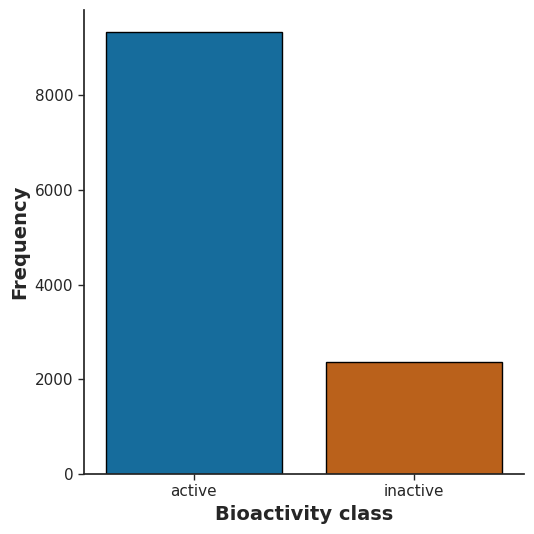

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks", font_scale=1.0)
palette = {"active": "#0072B2", "inactive": "#D55E00"}

fig, ax = plt.subplots(figsize=(5.5, 5.5))
sns.countplot(x='class', data=df_2class, order=['active', 'inactive'], hue='class',
              hue_order=['active', 'inactive'], palette=palette, edgecolor='black',
              linewidth=1.0, legend=False, ax=ax)
ax.set_xlabel('Bioactivity class', fontsize=14, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=11, width=1, length=4)
sns.despine(ax=ax)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('Figure2_Bioactivity_Class_Frequency.tiff', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

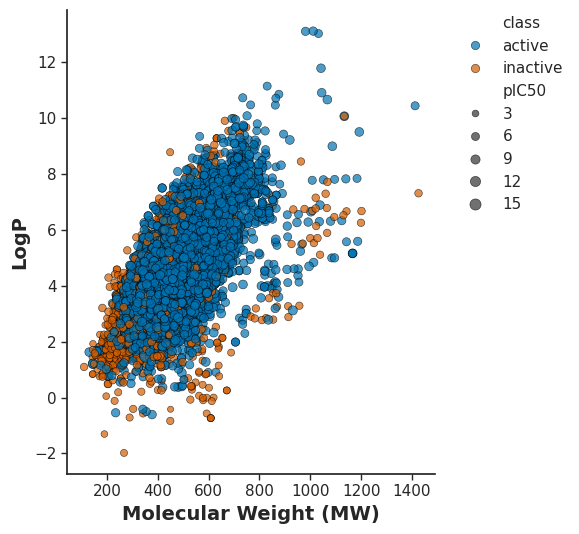

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5.5))
sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='class', hue_order=['active', 'inactive'],
                 palette=palette, size='pIC50', edgecolor='black', alpha=0.7, ax=ax)
ax.set_xlabel('Molecular Weight (MW)', fontsize=14, fontweight='bold')
ax.set_ylabel('LogP', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=11, width=1, length=4)
sns.despine(ax=ax)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0, frameon=False)
plt.tight_layout()
plt.savefig('Figure4a_LogP_vs_MW_scatter.tiff', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
def mannwhitney(descriptor, verbose=False):
    from numpy.random import seed
    from scipy.stats import mannwhitneyu

    seed(1)

    selection = [descriptor, 'class']
    d = df_2class[selection]
    active = d[d['class'] == 'active'][descriptor]

    d = df_2class[selection]
    inactive = d[d['class'] == 'inactive'][descriptor]

    stat, p = mannwhitneyu(active, inactive)

    alpha = 0.05
    interpretation = 'Same distribution (fail to reject H0)' if p > alpha else 'Different distribution (reject H0)'

    results = pd.DataFrame({'Descriptor': descriptor,
                             'Statistics': stat,
                             'p': p,
                             'alpha': alpha,
                             'Interpretation': interpretation}, index=[0])
    results.to_csv(f'mannwhitneyu_{descriptor}.csv', index=False)
    return results

mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,22067815.0,0.0,0.05,Different distribution (reject H0)


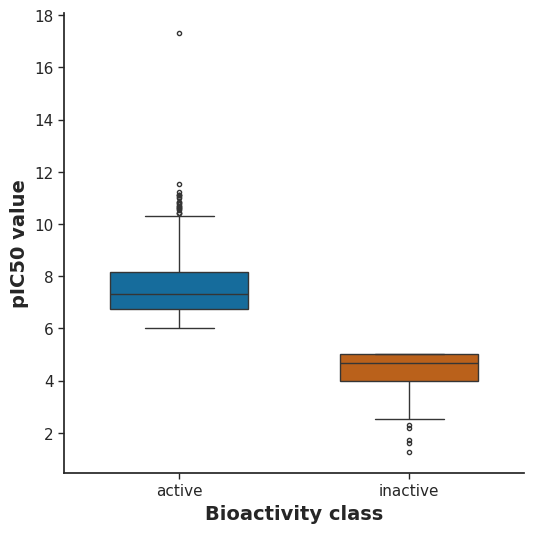

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
sns.boxplot(x='class', y='pIC50', data=df_2class, order=['active', 'inactive'], hue='class',
            hue_order=['active', 'inactive'], palette=palette, width=0.6, linewidth=1.0,
            fliersize=3, legend=False, ax=ax)
ax.set_xlabel('Bioactivity class', fontsize=14, fontweight='bold')
ax.set_ylabel('pIC50 value', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=11, width=1, length=4)
sns.despine(ax=ax)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('Figure4b_pIC50_boxplot.tiff', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

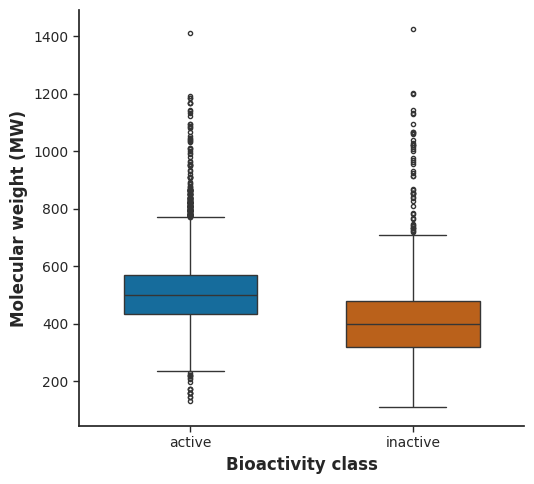

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,16167172.0,2.254451e-268,0.05,Different distribution (reject H0)


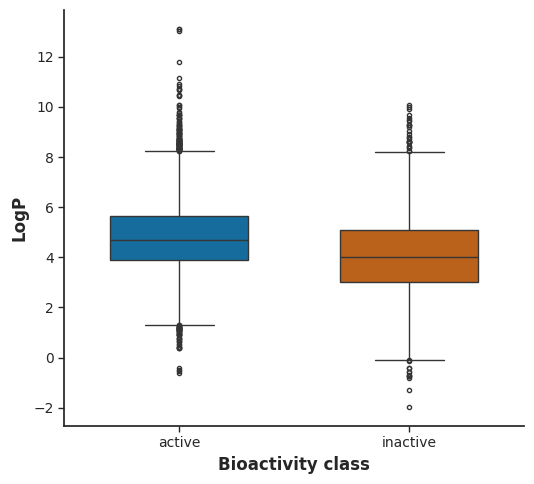

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,14089832.5,2.037998e-96,0.05,Different distribution (reject H0)


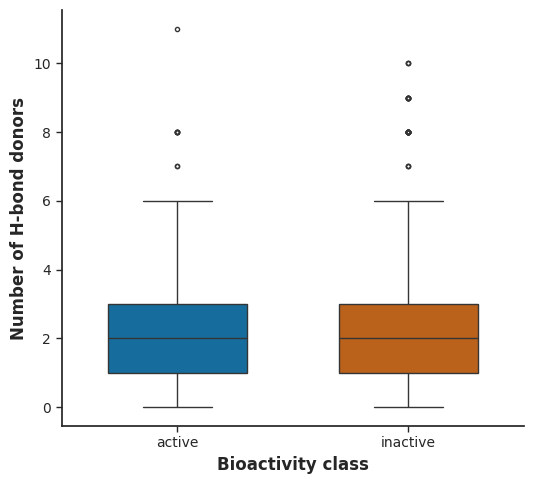

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,12749370.5,2.426312e-34,0.05,Different distribution (reject H0)


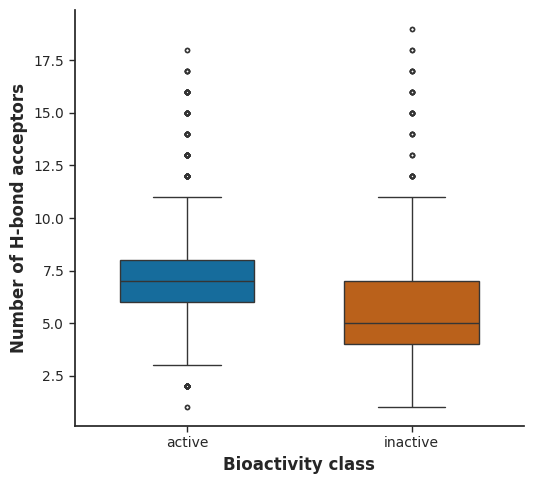

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,15902566.5,5.391427e-247,0.05,Different distribution (reject H0)


In [ ]:
label_names = {
    "MW": "Molecular weight (MW)",
    "LogP": "LogP",
    "NumHDonors": "Number of H-bond donors",
    "NumHAcceptors": "Number of H-bond acceptors"
}
panel_letters = {"LogP": "a", "MW": "b", "NumHDonors": "c", "NumHAcceptors": "d"}

for desc in ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']:
    fig, ax = plt.subplots(figsize=(5.5, 5.0))
    sns.boxplot(x='class', y=desc, data=df_2class, order=['active', 'inactive'], hue='class',
                hue_order=['active', 'inactive'], palette=palette, width=0.6, linewidth=1.0,
                fliersize=3, legend=False, ax=ax)
    ax.set_xlabel('Bioactivity class', fontsize=12, fontweight='bold')
    ax.set_ylabel(label_names[desc], fontsize=12, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=10, width=1, length=4)
    sns.despine(ax=ax)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    plt.tight_layout()
    plt.savefig(f'Figure3{panel_letters[desc]}_{desc}_boxplot.tiff', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    display(mannwhitney(desc))

In [ ]:
!apt-get install -y default-jre -qq
!pip install -q padelpy

Selecting previously unselected package libatspi2.0-0:amd64.
(Reading database ... 118422 files and directories currently installed.)
Preparing to unpack .../00-libatspi2.0-0_2.44.0-3_amd64.deb ...
Unpacking libatspi2.0-0:amd64 (2.44.0-3) ...
Selecting previously unselected package libxtst6:amd64.
Preparing to unpack .../01-libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package session-migration.
Preparing to unpack .../02-session-migration_0.3.6_amd64.deb ...
Unpacking session-migration (0.3.6) ...
Selecting previously unselected package gsettings-desktop-schemas.
Preparing to unpack .../03-gsettings-desktop-schemas_42.0-1ubuntu1_all.deb ...
Unpacking gsettings-desktop-schemas (42.0-1ubuntu1) ...
Selecting previously unselected package at-spi2-core.
Preparing to unpack .../04-at-spi2-core_2.44.0-3_amd64.deb ...
Unpacking at-spi2-core (2.44.0-3) ...
Selecting previously unselected package openjdk-11-jre-headless:a

In [ ]:
import pandas as pd

df3 = pd.read_csv('erbB1_bioactivity_data_3class_pIC50.csv')

selection = ['canonical_smiles', 'molecule_chembl_id']
df3_selection = df3[selection]
df3_selection.to_csv('molecule.smi', sep='\t', index=False, header=False)

print(len(df3_selection), 'molecules written to molecule.smi')

13577 molecules written to molecule.smi


In [ ]:
from padelpy import padeldescriptor

# padeldescriptor() bundles its own PaDEL-Descriptor.jar + PubchemFingerprinter.xml,
# so no manual jar/zip download is required anymore.
padeldescriptor(
    mol_dir='molecule.smi',
    d_file='descriptors_output.csv',
    fingerprints=True,          # PubChem fingerprints, same as the original padel.sh
    descriptortypes=None,       # None -> padelpy's default PubChem fingerprint config
    detectaromaticity=True,
    standardizenitro=True,
    standardizetautomers=True,
    threads=2,
    removesalt=True,
    log=True,
    retainorder=True,
)

df3_X = pd.read_csv('descriptors_output.csv')
df3_X.head()

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL68920,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL69960,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL137635,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL306988,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL66879,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df3_X = pd.read_csv('descriptors_output.csv')
df3_X = df3_X.rename(columns={'Name': 'molecule_chembl_id'})

dataset3 = df3_X.merge(df3[['molecule_chembl_id', 'pIC50']], on='molecule_chembl_id', how='inner')
print('Rows after merge:', len(dataset3))

dataset3.to_csv('erbB1_bioactivity_data_3class_pIC50_pubchem_fp.csv', index=False)

Rows after merge: 13577


In [ ]:
X = dataset3.drop(['pIC50', 'molecule_chembl_id'], axis=1)
Y = dataset3.pIC50

from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)
print(X.shape)

(13577, 147)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)
r2 = model.score(X_test, Y_test)
print('R2:', r2)

R2: 0.6462832273749377


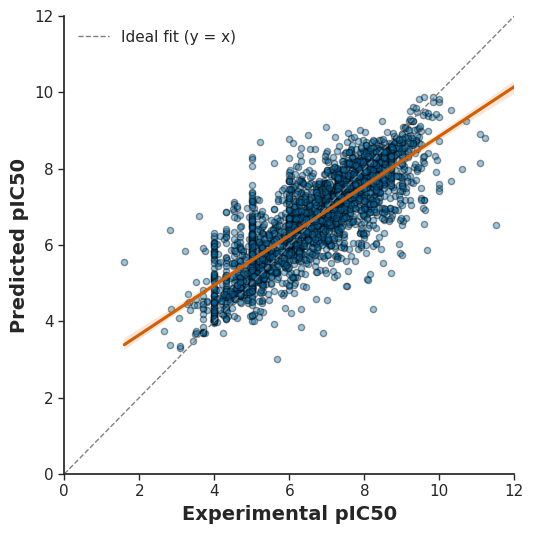

In [ ]:
Y_pred = model.predict(X_test)

sns.set_theme(style="ticks", font_scale=1.0)
plot_df = pd.DataFrame({'Experimental pIC50': Y_test, 'Predicted pIC50': Y_pred})

fig, ax = plt.subplots(figsize=(5.5, 5.5))
sns.regplot(x='Experimental pIC50', y='Predicted pIC50', data=plot_df,
            scatter_kws={'alpha': 0.4, 'color': '#0072B2', 'edgecolor': 'black', 's': 20},
            line_kws={'color': '#D55E00'}, ax=ax)
ax.plot([0, 12], [0, 12], linestyle='--', color='gray', linewidth=1, label='Ideal fit (y = x)')
ax.set_xlabel('Experimental pIC50', fontsize=14, fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize=14, fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.tick_params(axis='both', which='major', labelsize=11, width=1, length=4)
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('Figure5_Experimental_vs_Predicted_pIC50.tiff', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
!pip install -q lazypredict lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.1 MB/s eta 0:00:00


In [ ]:
import lazypredict
from lazypredict.Supervised import LazyRegressor

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

clf = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models_train, predictions_train = clf.fit(X_train, X_train, Y_train, Y_train)
models_test, predictions_test = clf.fit(X_train, X_test, Y_train, Y_test)

predictions_test

""


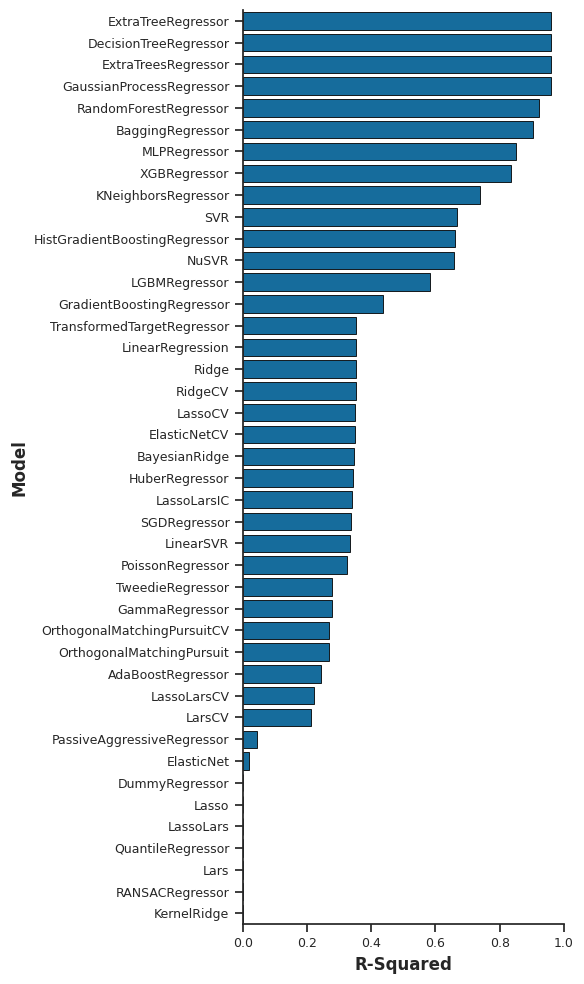

In [ ]:
fig, ax = plt.subplots(figsize=(6, 10))
sns.set_theme(style="ticks", font_scale=1.0)
sns.barplot(y=models_train.index, x="R-Squared", data=models_train, color='#0072B2',
            edgecolor='black', linewidth=0.6, ax=ax)
ax.set(xlim=(0, 1))
ax.set_xlabel('R-Squared', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=9)
sns.despine(ax=ax)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('Figure6a_LazyPredict_R2_barplot.tiff', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

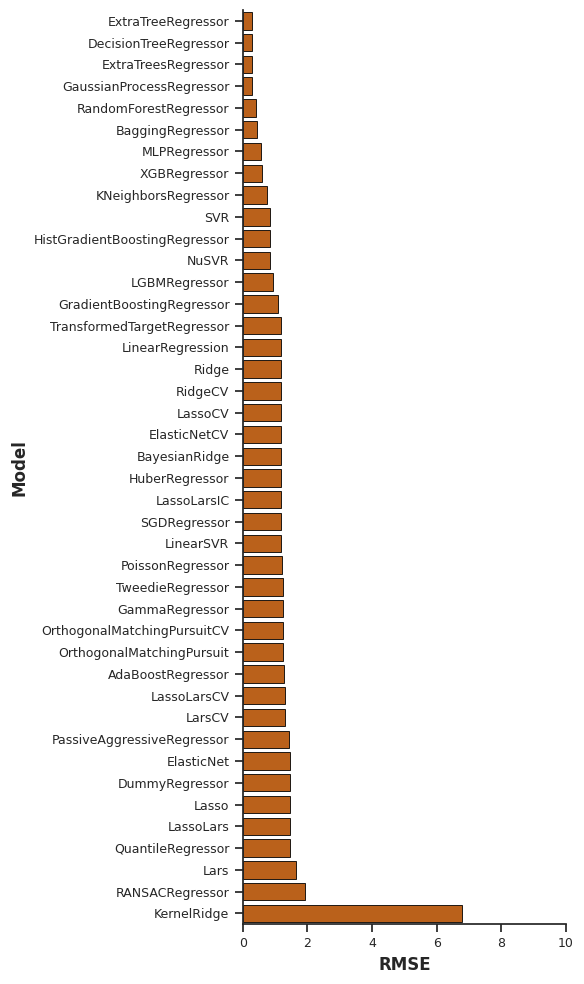

In [ ]:
fig, ax = plt.subplots(figsize=(6, 10))
sns.set_theme(style="ticks", font_scale=1.0)
sns.barplot(y=models_train.index, x="RMSE", data=models_train, color='#D55E00',
            edgecolor='black', linewidth=0.6, ax=ax)
ax.set(xlim=(0, 10))
ax.set_xlabel('RMSE', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=9)
sns.despine(ax=ax)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('Figure6b_LazyPredict_RMSE_barplot.tiff', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

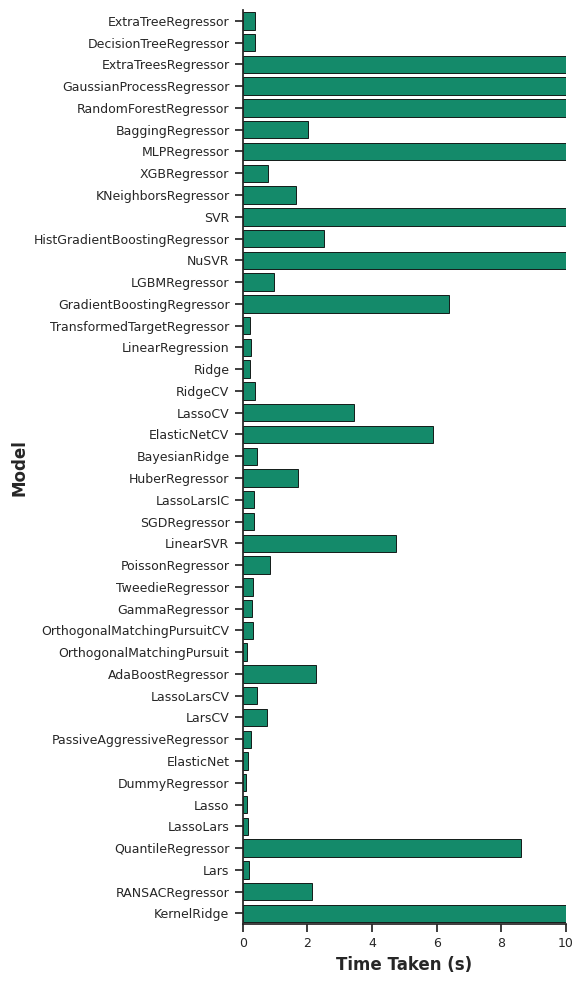

In [ ]:
fig, ax = plt.subplots(figsize=(6, 10))
sns.set_theme(style="ticks", font_scale=1.0)
sns.barplot(y=models_train.index, x="Time Taken", data=models_train, color='#009E73',
            edgecolor='black', linewidth=0.6, ax=ax)
ax.set(xlim=(0, 10))
ax.set_xlabel('Time Taken (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=9)
sns.despine(ax=ax)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('FigureS1_LazyPredict_TimeTaken_barplot.tiff', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor

et_model = ExtraTreesRegressor(n_estimators=100, random_state=42)
dt_model = DecisionTreeRegressor(random_state=42)

et_model.fit(X_train, Y_train)
dt_model.fit(X_train, Y_train)

print('ExtraTreesRegressor  R2:', et_model.score(X_test, Y_test))
print('DecisionTreeRegressor R2:', dt_model.score(X_test, Y_test))

ExtraTreesRegressor  R2: 0.4494400545843793
DecisionTreeRegressor R2: 0.40592757659943735


In [ ]:
import joblib
joblib.dump(et_model, 'et_model.pkl')
joblib.dump(dt_model, 'dt_model.pkl')
print('Models saved.')

Models saved.


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import ExtraTreesRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(ExtraTreesRegressor(n_estimators=100, random_state=42), X, Y, cv=cv, scoring='r2')
print('CV R2 mean:', scores.mean(), '+/-', scores.std())

CV R2 mean: 0.4582260743924456 +/- 0.016051162665080408


In [ ]:
et_model_tuned = ExtraTreesRegressor(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
scores = cross_val_score(et_model_tuned, X, Y, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2')
print('Tuned CV R2 mean:', scores.mean(), '+/-', scores.std())

Tuned CV R2 mean: 0.6628618562354053 +/- 0.007645215452565888


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
scores = cross_val_score(GradientBoostingRegressor(random_state=42), X, Y, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2')
print('GBR CV R2 mean:', scores.mean(), '+/-', scores.std())

GBR CV R2 mean: 0.4158950944233573 +/- 0.009095995157019055


In [ ]:
final_model = ExtraTreesRegressor(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X, Y)

import joblib
joblib.dump(final_model, 'et_model_final.pkl')
print('Final model saved.')

Final model saved.


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import ExtraTreesRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = cross_val_score(
    ExtraTreesRegressor(n_estimators=500, max_features='sqrt', min_samples_leaf=2, random_state=42, n_jobs=-1),
    X, Y, cv=cv, scoring='neg_root_mean_squared_error'
)

rmse_scores = -rmse_scores  # sklearn returns negative RMSE by convention
print('CV RMSE mean:', rmse_scores.mean(), '+/-', rmse_scores.std())

CV RMSE mean: 0.8558844263077662 +/- 0.00828610789743151


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import ExtraTreesRegressor
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)

Y_shuffled = np.random.RandomState(42).permutation(Y)

real_scores = cross_val_score(
    ExtraTreesRegressor(n_estimators=500, max_features='sqrt', min_samples_leaf=2, random_state=42, n_jobs=-1),
    X, Y, cv=cv, scoring='r2'
)
shuffled_scores = cross_val_score(
    ExtraTreesRegressor(n_estimators=500, max_features='sqrt', min_samples_leaf=2, random_state=42, n_jobs=-1),
    X, Y_shuffled, cv=cv, scoring='r2'
)

print('Real labels    R2:', real_scores.mean(), '+/-', real_scores.std())
print('Shuffled labels R2:', shuffled_scores.mean(), '+/-', shuffled_scores.std())

Real labels    R2: 0.6628618562354053 +/- 0.007645215452565926
Shuffled labels R2: -0.12766656454137482 +/- 0.008338864862340008


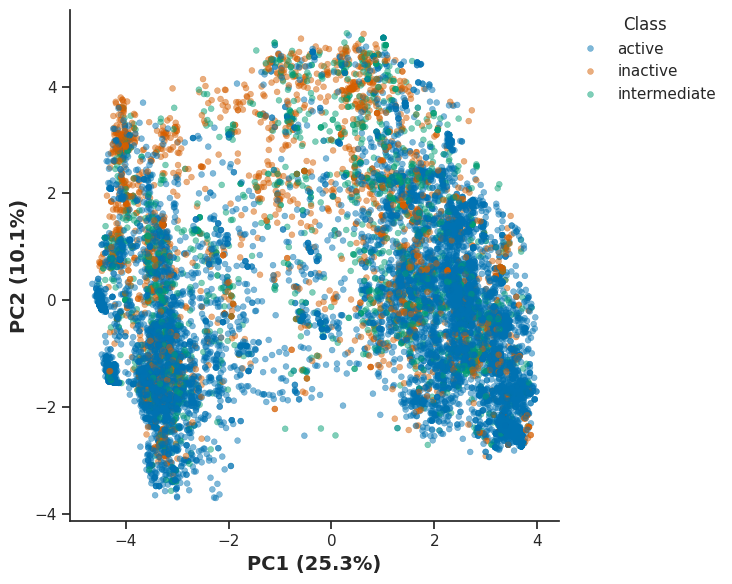

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", font_scale=1.0)
palette3 = {"active": "#0072B2", "inactive": "#D55E00", "intermediate": "#009E73"}

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# merge in the active/inactive/intermediate class label via molecule_chembl_id
pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1]})
pca_df['molecule_chembl_id'] = dataset3['molecule_chembl_id'].values
pca_df = pca_df.merge(df3[['molecule_chembl_id', 'class']], on='molecule_chembl_id', how='left')

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.scatterplot(x='PC1', y='PC2', hue='class', hue_order=['active', 'inactive', 'intermediate'],
                 palette=palette3, data=pca_df, alpha=0.5, edgecolor=None, s=18, ax=ax)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=14, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=11)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, frameon=False, title='Class')
sns.despine(ax=ax)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('Figure7_PCA_Chemical_Space.tiff', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

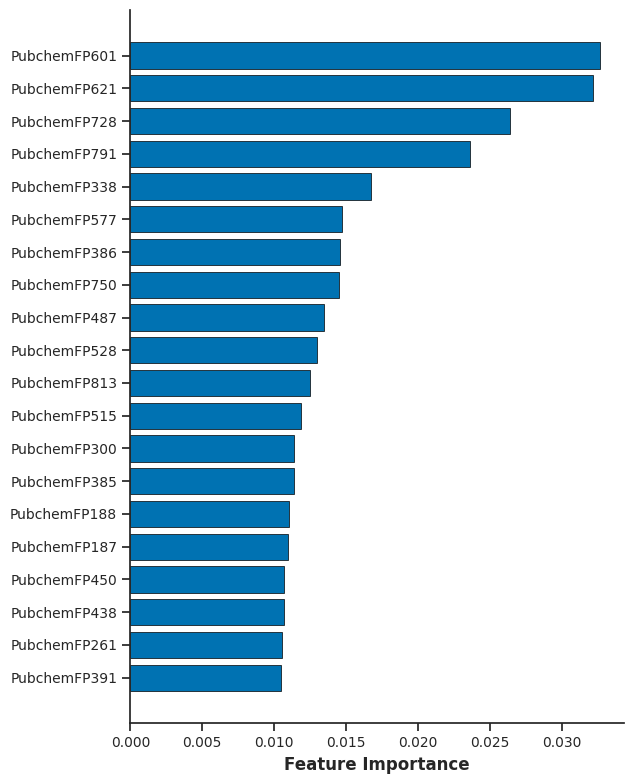

['PubchemFP601', 'PubchemFP621', 'PubchemFP728', 'PubchemFP791', 'PubchemFP338', 'PubchemFP577', 'PubchemFP386', 'PubchemFP750', 'PubchemFP487', 'PubchemFP528', 'PubchemFP813', 'PubchemFP515', 'PubchemFP300', 'PubchemFP385', 'PubchemFP188', 'PubchemFP187', 'PubchemFP450', 'PubchemFP438', 'PubchemFP261', 'PubchemFP391']


In [ ]:
import seaborn as sns

# Get the original PubChem column names that survived VarianceThreshold
original_feature_names = dataset3.drop(['pIC50', 'molecule_chembl_id'], axis=1).columns
surviving_mask = selection.get_support()  # from your earlier VarianceThreshold fit
surviving_names = original_feature_names[surviving_mask]

importances = final_model.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(6.5, 8))
ax.barh(range(top_n), importances[top_idx][::-1], color='#0072B2', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(surviving_names[top_idx][::-1], fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelsize=10)
sns.despine(ax=ax)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('Figure8_Feature_Importance.tiff', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(surviving_names[top_idx].tolist())

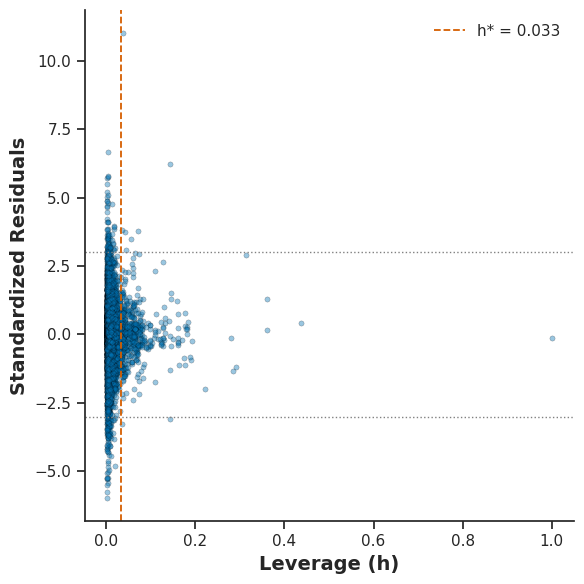

699 of 13577 compounds fall outside the applicability domain (5.1%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

X_arr = np.asarray(X)
n, p = X_arr.shape

# Leverage (hat) values: h_ii from the hat matrix X(X'X)^-1X'
XtX_inv = np.linalg.pinv(X_arr.T @ X_arr)
leverage = np.einsum('ij,jk,ik->i', X_arr, XtX_inv, X_arr)

Y_pred_full = final_model.predict(X_arr)
residuals = np.asarray(Y) - Y_pred_full
std_residuals = residuals / residuals.std()

h_star = 3 * (p + 1) / n  # standard warning leverage threshold

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(leverage, std_residuals, alpha=0.4, s=14, color='#0072B2', edgecolor='black', linewidth=0.3)
ax.axvline(h_star, color='#D55E00', linestyle='--', linewidth=1.3, label=f'h* = {h_star:.3f}')
ax.axhline(3, color='gray', linestyle=':', linewidth=1)
ax.axhline(-3, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Leverage (h)', fontsize=14, fontweight='bold')
ax.set_ylabel('Standardized Residuals', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=11)
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('Figure10_Williams_Applicability_Domain.tiff', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

outside_domain = ((leverage > h_star) | (np.abs(std_residuals) > 3)).sum()
print(f'{outside_domain} of {n} compounds fall outside the applicability domain ({outside_domain/n:.1%})')

In [ ]:
import glob
import zipfile
from google.colab import files

tiff_files = sorted(glob.glob('*.tiff'))
print(f"Found {len(tiff_files)} TIFF figures:")
for f in tiff_files:
    print(" -", f)

with zipfile.ZipFile('EGFR_erbB1_figures.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in tiff_files:
        zf.write(f)

files.download('EGFR_erbB1_figures.zip')

Found 14 TIFF figures:
 - Figure10_Williams_Applicability_Domain.tiff
 - Figure2_Bioactivity_Class_Frequency.tiff
 - Figure3a_LogP_boxplot.tiff
 - Figure3b_MW_boxplot.tiff
 - Figure3c_NumHDonors_boxplot.tiff
 - Figure3d_NumHAcceptors_boxplot.tiff
 - Figure4a_LogP_vs_MW_scatter.tiff
 - Figure4b_pIC50_boxplot.tiff
 - Figure5_Experimental_vs_Predicted_pIC50.tiff
 - Figure6a_LazyPredict_R2_barplot.tiff
 - Figure6b_LazyPredict_RMSE_barplot.tiff
 - Figure7_PCA_Chemical_Space.tiff
 - Figure8_Feature_Importance.tiff
 - FigureS1_LazyPredict_TimeTaken_barplot.tiff


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>